<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke07-velferdsteknologi/03_beslutningsstøtte_i_hjem_og_omsorg.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 10-25 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig
- Data: syntetisk/simulert data
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [1]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# 🏡 Beslutningsstøtte i hjem og omsorg

I forrige notebook så vi hvordan sensorer kan gi rå signaler om aktivitet og mulige avvik. I denne notebooken tar vi neste steg: Hvordan kan slike signaler omsettes til varsler, prioriteringer og beslutningsstøtte for ansatte i hjem og omsorg?

Den sentrale utfordringen er at et system ikke bare skal oppdage noe, men også bidra til riktig oppfølging. Dermed beveger vi oss fra tolkning av hendelser til vurdering av hvilke situasjoner som bør løftes fram, og hvordan teknologi kan støtte uten å overta det faglige ansvaret.

## Læringsmål
- beskrive hvordan AI kan brukes til prioritering og varsling i omsorgstjenester
- forstå forskjellen mellom støtte og autonom beslutning
- diskutere risiko ved overvarsling og feilvarsling
- reflektere over nytte opp mot belastning for bruker og tjeneste

### 🔧 Miljøoppsett – fungerer både lokalt og i Google Colab

In [2]:
import sys, os, subprocess
import pandas as pd
import matplotlib.pyplot as plt

# Vi sjekker om notebooken kjører i Google Colab.
# Det er nyttig fordi filstier og arbeidsmappe ofte må håndteres annerledes der enn lokalt.
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")

    # Dersom repoet ikke finnes i den aktive Colab-økten, henter vi det fra GitHub.
    # Da får notebooken tilgang til samme struktur som ved lokal kjøring.
    if not os.path.exists('AI-og-helse'):
        print("📥 Laster ned kursmateriell...")
        subprocess.check_call(["git", "clone", "https://github.com/arvidl/AI-og-helse.git"])

    # Når repoet finnes, bytter vi til riktig arbeidsmappe slik at relative stier fungerer.
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Byttet til mappe: {os.getcwd()}")
else:
    # Ved lokal kjøring antar vi at brukeren allerede står i prosjektmappen.
    print("💻 Kjører i lokalt miljø")

# Vi setter en standard figurstørrelse slik at visualiseringene blir lettere å lese.
plt.rcParams['figure.figsize'] = (9, 4)

print("✅ Miljø klart")

💻 Kjører i lokalt miljø
✅ Miljø klart


## Når bør systemet varsle?

I hjemmetjeneste og omsorg er utfordringen sjelden å lage flest mulig varsler. Utfordringen er å lage **gode nok varsler**.

Et beslutningsstøttesystem må derfor balansere:

- å oppdage reelle problemer tidlig
- å unngå for mange unødige alarmer
- å presentere informasjon på en måte som faktisk hjelper ansatte

For mange varsler kan skape **alarmtretthet**. For få varsler kan gjøre at viktige hendelser overses.

In [3]:
# Vi lager en liten, syntetisk varslingsliste for hjemmeoppfølging.
# Eksempelet viser hvordan et system kan samle informasjon om flere brukere
# og støtte prioritering av hvem som bør følges opp først.

data = pd.DataFrame({
    'bruker': ['A', 'B', 'C', 'D', 'E'],
    'risikoskår': [0.82, 0.41, 0.67, 0.25, 0.91],
    'antall_signaler': [5, 1, 3, 1, 6],
    'klinisk_kontekst': ['høy', 'lav', 'middels', 'lav', 'høy']
})

# 'risikoskår' kan forstås som en samlet vurdering fra et beslutningsstøttesystem.
# 'antall_signaler' sier hvor mange observasjoner eller varsler som ligger bak.
# 'klinisk_kontekst' minner oss om at samme skår kan bety ulike ting avhengig av situasjonen.

data

,bruker,risikoskår,antall_signaler,klinisk_kontekst
0,A,0.82,5,høy
1,B,0.41,1,lav
2,C,0.67,3,middels
3,D,0.25,1,lav
4,E,0.91,6,høy


In [4]:
# Her lager vi en enkel regel for hvordan varsler kan prioriteres.
# Målet er å illustrere at et beslutningsstøttesystem ikke bare beregner risiko,
# men også ofte brukes til å foreslå hva slags oppfølging som bør vurderes.

def prioriter(rad):
    # Høy risikoskår kombinert med høy klinisk kontekst gir rask oppfølging.
    # Dette illustrerer at både tall og situasjon må tas med i vurderingen.
    if rad['risikoskår'] >= 0.80 and rad['klinisk_kontekst'] == 'høy':
        return 'Rask oppfølging'

    # Middels til høy risiko kan tilsi at saken bør vurderes samme dag,
    # selv om den ikke nødvendigvis krever umiddelbar handling.
    if rad['risikoskår'] >= 0.60:
        return 'Vurderes i løpet av dagen'

    # Lavere skårer fører her til ingen umiddelbar handling,
    # men i praksis ville dette fortsatt kreve faglig vurdering og kontekstforståelse.
    return 'Ingen umiddelbar handling'

# Vi bruker regelen på hver rad i tabellen og lager en ny kolonne med anbefaling.
data['anbefaling'] = data.apply(prioriter, axis=1)

# Resultatet viser hvordan samme datasett kan oversettes til ulike prioriteringsnivåer.
data

,bruker,risikoskår,antall_signaler,klinisk_kontekst,anbefaling
0,A,0.82,5,høy,Rask oppfølging
1,B,0.41,1,lav,Ingen umiddelbar handling
2,C,0.67,3,middels,Vurderes i løpet av dagen
3,D,0.25,1,lav,Ingen umiddelbar handling
4,E,0.91,6,høy,Rask oppfølging


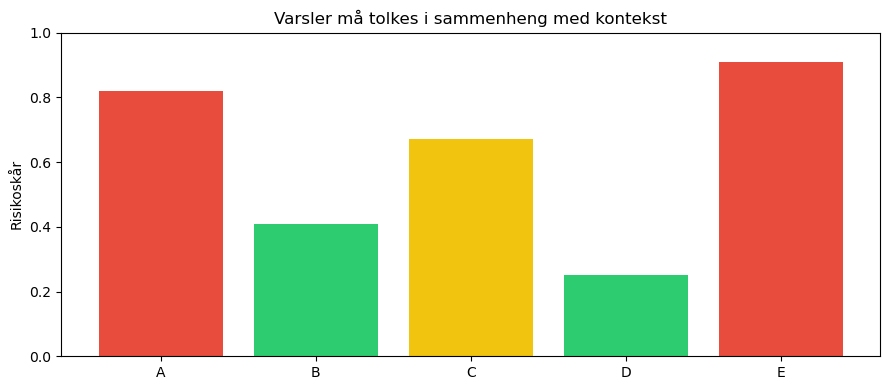

In [5]:
# Vi visualiserer risikoskårene for de ulike brukerne som et stolpediagram.
# Det gjør det lettere å sammenligne hvem systemet vurderer som mest kritiske.

# Fargene brukes for å markere ulike nivåer av risiko:
# rød for høy, gul for middels og grønn for lavere risikonivå.
plt.bar(
    data['bruker'],
    data['risikoskår'],
    color=['#e74c3c' if x >= 0.8 else '#f1c40f' if x >= 0.6 else '#2ecc71' for x in data['risikoskår']]
)

# Risikoskår er her definert mellom 0 og 1, så vi setter aksen tilsvarende.
plt.ylim(0, 1)
plt.ylabel('Risikoskår')
plt.title('Varsler må tolkes i sammenheng med kontekst')
plt.tight_layout()
plt.show()

### Refleksjon
- Når bør et system bare gi støtteinformasjon, og når bør det foreslå handling?
- Hva er risikoen ved å stole for mye på en risikoskår uten kontekst?
- Hvordan kan man redusere alarmtretthet i et slikt system?

## Oppsummering

Denne notebooken viser hvordan syntetiske signaler og risikoskårer kan omsettes til prioritering og beslutningsstøtte i hjem og omsorg. Eksempelet understreker at slike systemer bør støtte faglige vurderinger, ikke erstatte dem.

Videre i uke 07 samler vi trådene i spørsmål om sikkerhet, etikk, ansvar og menneske-maskin-samspill.